# Notebook 6 — Interpretability + Cross-Dataset Ablation + Devzohaib Strict Subset
### DEEP-LEARNING BASED EMOTION RECOGNITION IN BANGLADESHI STREET DOGS
**Final EAAI experimental package — three deliverables in one notebook**

This notebook executes three remaining experiments needed to complete the experimental story:

**Part A — Prototype Interpretability (Tier 2 #4 + #5)**
- Activation heatmap: 18 prototypes × {A, N, H} mean activation on BDSE test data
- Per-prototype activation alignment with anchored class
- Top-k activating images per prototype (visual evidence that prototypes track ethogram criteria)
- Anchor drift analysis: cosine similarity between trained prototypes and original text anchors

**Part B — Cross-Dataset Ablation (Tier 2 #6)**
- Train PEACE-full / PEACE-no-DAD / PEACE-no-ADaS / PEACE-no-anchor on BDSE
- Evaluate transfer to Shanbalico, Devzohaib, DEBIw(A/N) with 5 seeds each
- Confirms each PEACE component contributes to cross-dataset robustness, not just in-domain

**Part C — Devzohaib Strict Subset (Tier 3 #10)**
- Re-evaluate BDSE → Devzohaib transfer using only `bdse_strict_subset` (dog_conf ≥ 0.6)
- Tests whether PEACE's transfer advantage grows when label noise is reduced
- 5 seeds, paired comparison vs full subset

**Outputs:**
- `prototype_activation_heatmap.csv` + `figure_prototype_activation.pdf`
- `prototype_anchor_drift.csv` + `figure_anchor_drift.pdf`
- `top10_activating_images_grid.pdf` (18-panel)
- `cross_dataset_ablation_results.csv` + `figure_ablation.pdf`
- `devzohaib_strict_subset_comparison.csv` + `figure_strict_subset.pdf`

**Compute:** ~3 GPU-hours total

In [1]:
%%capture
!pip install transformers accelerate scikit-learn scipy matplotlib seaborn pillow requests -q


In [2]:
import os, sys, json, time, warnings, gc
import numpy as np
import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import wilcoxon, t as student_t
from sklearn.metrics import f1_score, balanced_accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedShuffleSplit
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from PIL import Image
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU: {p.name}  VRAM: {p.total_memory/1e9:.1f} GB")

Device: cuda
GPU: Tesla T4  VRAM: 15.6 GB


In [3]:
CFG = dict(
    bdse_feat_dir       = '/kaggle/input/datasets/rohulaminlabid/phase1-nb2-inputs',
    manifests_dir       = '/kaggle/input/datasets/rohulaminlabid/benchmard-datasets',
    bdse_image_dir      = '/kaggle/input/datasets/rohulaminlabid/bdse-dataset/bdse',
    shanbalico_img_dir  = '/kaggle/input/datasets/danielshanbalico/dog-emotion/Dog Emotion',
    devzohaib_img_dir   = '/kaggle/input/datasets/devzohaib/dog-emotions-prediction/images',
    debiw_img_dir       = '/kaggle/input/datasets/rohulaminlabid/debiw-dataset',
    feat_cache_dir      = '/kaggle/working/feat_cache',
    output_dir          = '/kaggle/working/nb6_outputs',

    siglip_id           = 'google/siglip-base-patch16-224',
    feat_dim            = 768,
    extract_batch       = 64,

    n_proto_per_class   = 6,
    tau                 = 0.07,
    lambda_anchor       = 0.1,
    mu_div              = 0.05,
    lr                  = 1e-3,
    epochs              = 150,
    patience            = 20,
    batch_size          = 256,

    n_seeds_ablation    = 5,
    seeds_ablation      = [13, 42, 101, 257, 999],
    indomain_test_frac  = 0.20,

    classes3            = ['A', 'N', 'H'],
    classes2            = ['A', 'N'],
    debiw_workers       = 20,
    debiw_timeout       = 12,
    debiw_retries       = 2,

    top_k_activating    = 10,    # number of top images per prototype to save
)

for d in [CFG['debiw_img_dir'], CFG['feat_cache_dir'], CFG['output_dir']]:
    os.makedirs(d, exist_ok=True)

CLASS3_TO_IDX = {c: i for i, c in enumerate(CFG['classes3'])}
CLASS2_TO_IDX = {c: i for i, c in enumerate(CFG['classes2'])}
print("Config loaded.")

Config loaded.


In [6]:
# Load SigLIP once; keep frozen on GPU for feature extraction
from transformers import AutoProcessor, AutoModel

print("Loading SigLIP-Base/16 …")
_siglip_processor = AutoProcessor.from_pretrained(CFG['siglip_id'])
_siglip_model     = AutoModel.from_pretrained(CFG['siglip_id']).to(DEVICE).eval()
for p in _siglip_model.parameters():
    p.requires_grad_(False)
print("SigLIP loaded.")

def siglip_image_features(image_paths, batch_size=None):
    """Return L2-normalised SigLIP image features (N, 768) for a list of paths.
    Invalid / missing images are replaced with zero vectors; returned valid_mask
    is a boolean array marking which rows are real."""
    bs = batch_size or CFG['extract_batch']
    all_feats, valid_mask = [], []
    for i in range(0, len(image_paths), bs):
        batch = image_paths[i:i+bs]
        imgs, ok = [], []
        for p in batch:
            try:
                imgs.append(Image.open(p).convert('RGB'))
                ok.append(True)
            except Exception:
                imgs.append(Image.new('RGB', (224, 224), 0))
                ok.append(False)
        inp = _siglip_processor(images=imgs, return_tensors='pt', padding=True)
        inp = {k: v.to(DEVICE) for k, v in inp.items()}
        with torch.no_grad():
            outputs = _siglip_model.get_image_features(**inp)
            feats = outputs.pooler_output  # This extracts the actual feature tensor
            feats = F.normalize(feats, dim=1)
        all_feats.append(feats.cpu().numpy())
        valid_mask.extend(ok)
        if (i // bs) % 20 == 0:
            print(f"  {i+len(batch)}/{len(image_paths)} images processed", end='\r')
    print()
    return np.concatenate(all_feats, axis=0), np.array(valid_mask, dtype=bool)

def siglip_text_features(texts):
    """Return L2-normalised SigLIP text features for a list of strings."""
    inp = _siglip_processor(text=texts, return_tensors='pt', padding=True, truncation=True)
    inp = {k: v.to(DEVICE) for k, v in inp.items()}
    with torch.no_grad():
        outputs = _siglip_model.get_image_features(**inp)
        feats = outputs.pooler_output  # This extracts the actual tensor
        feats = F.normalize(feats, dim=1)
    return feats.cpu().numpy()

def cache_path(name):
    return os.path.join(CFG['feat_cache_dir'], f'{name}.npy')

def load_or_extract(name, image_paths, label_array):
    """Load cached features or extract and cache them."""
    fp = cache_path(name)
    fp_meta = fp.replace('.npy', '_meta.csv')
    if os.path.exists(fp) and os.path.exists(fp_meta):
        print(f"[cache hit] {name}")
        feats = np.load(fp)
        meta  = pd.read_csv(fp_meta)
        return feats, meta
    print(f"[extracting] {name} ({len(image_paths)} images) …")
    feats, valid = siglip_image_features(image_paths)
    meta = pd.DataFrame({'path': image_paths, 'label': label_array, 'valid': valid})
    np.save(fp, feats)
    meta.to_csv(fp_meta, index=False)
    print(f"  Saved to {fp}")
    return feats, meta


Loading SigLIP-Base/16 …


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

SigLIP loaded.


In [25]:
print("Loading BDSE Phase 1 artifacts …")
bdse_feats_siglip = np.load(os.path.join(CFG['bdse_feat_dir'], 'features_siglip.npy'))
bdse_feat_index   = pd.read_csv(os.path.join(CFG['bdse_feat_dir'], 'feature_index.csv'))
text_anchors_np   = np.load(os.path.join(CFG['bdse_feat_dir'], 'text_anchors_siglip.npy'))
text_anchors_meta = pd.read_csv(os.path.join(CFG['bdse_feat_dir'], 'text_anchors_meta.csv'))

splits_path = os.path.join(CFG['bdse_feat_dir'], 'bdse_dogid_splits.csv')
if not os.path.exists(splits_path):
    splits_path = os.path.join(CFG['manifests_dir'], 'bdse_dogid_splits.csv')
bdse_splits = pd.read_csv(splits_path)
bdse_merged = bdse_feat_index.merge(bdse_splits[['image_id','dog_id','label','fold']],
                                     on='image_id', how='inner')
bdse_X = bdse_feats_siglip[bdse_merged.index.values]
bdse_y = bdse_merged['label_x'].map(CLASS3_TO_IDX).values
bdse_folds = bdse_merged['fold'].values
bdse_image_ids = bdse_merged['image_id'].values

# Try to find image paths for BDSE (used by top-k visualization)
bdse_image_paths = None
if 'filepath' in bdse_merged.columns:
    bdse_image_paths = bdse_merged['filepath'].values
elif os.path.isdir(CFG['bdse_image_dir']):
    # Try to construct paths from class folder structure
    label_to_dir = {'A':'angry', 'N':'neutral', 'H':'happy'}
    cand_paths = []
    for _, row in bdse_merged.iterrows():
        lbl_dir = label_to_dir.get(row['label_x'], row['label_x'])
        # Try a few extensions
        for ext in ['.jpg', '.jpeg', '.png', '.webp']:
            p = os.path.join(CFG['bdse_image_dir'], lbl_dir, f"{row['image_id']}{ext}")
            if os.path.exists(p):
                cand_paths.append(p); break
        else:
            cand_paths.append(None)
    bdse_image_paths = np.array(cand_paths)
    print(f"BDSE image paths found: {sum(1 for p in cand_paths if p is not None)}/{len(cand_paths)}")

# ADaS
adas_cols = ['n_A', 'n_N', 'n_H']
if all(c in bdse_merged.columns for c in adas_cols):
    totals = bdse_merged[adas_cols].sum(axis=1).clip(lower=1)
    bdse_soft = (bdse_merged[adas_cols].values / totals.values[:,None]).astype(np.float32)
    bdse_wts  = (totals / totals.max()).values.astype(np.float32)
else:
    bdse_soft = np.eye(3)[bdse_y].astype(np.float32)
    bdse_wts  = np.ones(len(bdse_y), dtype=np.float32)

TEXT_ANCHORS = torch.tensor(text_anchors_np, dtype=torch.float32)
PROTO_CLASS_MAP3 = {0: list(range(0,6)), 1: list(range(6,12)), 2: list(range(12,18))}
PROTO_CLASS_MAP2 = {0: list(range(0,6)), 1: list(range(6,12))}

# Anchor metadata (criterion IDs)
ANCHOR_LABELS = text_anchors_meta['criterion_id'].values   # ['A1', 'A2', ..., 'H6']
ANCHOR_TEXTS  = text_anchors_meta['criterion_text'].values
ANCHOR_CLASSES = text_anchors_meta['class'].values

print(f"BDSE rows: {len(bdse_merged)}  Text anchors: {TEXT_ANCHORS.shape}")

Loading BDSE Phase 1 artifacts …
BDSE image paths found: 0/500
BDSE rows: 500  Text anchors: torch.Size([18, 768])


In [9]:

debiw_manifest = pd.read_csv(os.path.join(CFG['manifests_dir'], 'debiw_processed.csv'))


In [10]:
shan_manifest = pd.read_csv(os.path.join(CFG['manifests_dir'], 'shanbalico_processed.csv'))
shan_main = shan_manifest[shan_manifest['bdse_used_for_main_eval']==True].reset_index(drop=True)
def res_shan(fp):
    fn = os.path.basename(fp); cls = fp.split('/')[-2]
    return os.path.join(CFG['shanbalico_img_dir'], cls, fn)
shan_paths = [res_shan(p) for p in shan_main['filepath']]
shan_X_raw, shan_meta = load_or_extract('shanbalico_main', shan_paths, shan_main['bdse_label'].values)
shan_v = shan_meta['valid'].values.astype(bool)
shan_X = shan_X_raw[shan_v]; shan_y3 = shan_meta['label'][shan_v].map(CLASS3_TO_IDX).values

dev_manifest = pd.read_csv(os.path.join(CFG['manifests_dir'], 'devzohaib_processed.csv'))
dev_main = dev_manifest[dev_manifest['bdse_used_for_main_eval']==True].reset_index(drop=True)
def res_dev(fp):
    parts = fp.split('/'); return os.path.join(CFG['devzohaib_img_dir'], parts[-2], parts[-1])
dev_paths = [res_dev(p) for p in dev_main['filepath']]
dev_X_raw, dev_meta = load_or_extract('devzohaib_main', dev_paths, dev_main['bdse_label'].values)
dev_v = dev_meta['valid'].values.astype(bool)
dev_X = dev_X_raw[dev_v]; dev_y3 = dev_meta['label'][dev_v].map(CLASS3_TO_IDX).values

# Devzohaib STRICT subset: bdse_strict_subset==True (dog_conf >= 0.6)
dev_strict_main = dev_manifest[(dev_manifest['bdse_used_for_main_eval']==True) &
                                (dev_manifest['bdse_strict_subset']==True)].reset_index(drop=True)
dev_strict_paths = [res_dev(p) for p in dev_strict_main['filepath']]
dev_strict_X_raw, dev_strict_meta = load_or_extract('devzohaib_strict',
                                                     dev_strict_paths,
                                                     dev_strict_main['bdse_label'].values)
dev_strict_v = dev_strict_meta['valid'].values.astype(bool)
dev_strict_X = dev_strict_X_raw[dev_strict_v]
dev_strict_y3 = dev_strict_meta['label'][dev_strict_v].map(CLASS3_TO_IDX).values

# DEBIw
debiw_main = debiw_manifest[debiw_manifest['bdse_used_for_main_eval']==True].reset_index(drop=True)
debiw_paths = [os.path.join(CFG['debiw_img_dir'], fn) for fn in debiw_main['image_filename']]
debiw_X_raw, debiw_meta = load_or_extract('debiw_main', debiw_paths, debiw_main['bdse_label'].values)
debiw_v = debiw_meta['valid'].values.astype(bool)
debiw_X = debiw_X_raw[debiw_v]; debiw_y2 = debiw_meta['label'][debiw_v].map(CLASS2_TO_IDX).values

print(f"Shan:        {shan_X.shape}")
print(f"Devzohaib:   {dev_X.shape}  classes: {dict(zip(*np.unique(dev_y3, return_counts=True)))}")
print(f"Dev STRICT:  {dev_strict_X.shape}  classes: {dict(zip(*np.unique(dev_strict_y3, return_counts=True)))}")
print(f"DEBIw:       {debiw_X.shape}")

[extracting] shanbalico_main (3000 images) …
  2624/3000 images processed
  Saved to /kaggle/working/feat_cache/shanbalico_main.npy
[extracting] devzohaib_main (8410 images) …
  7744/8410 images processed
  Saved to /kaggle/working/feat_cache/devzohaib_main.npy
[extracting] devzohaib_strict (6657 images) …
  6464/6657 images processed
  Saved to /kaggle/working/feat_cache/devzohaib_strict.npy
[extracting] debiw_main (5335 images) …


The channel dimension is ambiguous. Got image shape torch.Size([3, 1, 1]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.


  5184/5335 images processed
  Saved to /kaggle/working/feat_cache/debiw_main.npy
Shan:        (3000, 768)
Devzohaib:   (8410, 768)  classes: {np.int64(0): np.int64(1549), np.int64(1): np.int64(3057), np.int64(2): np.int64(3804)}
Dev STRICT:  (6657, 768)  classes: {np.int64(0): np.int64(1167), np.int64(1): np.int64(2348), np.int64(2): np.int64(3142)}
DEBIw:       (5335, 768)


In [18]:
class PEACEHead(nn.Module):
    def __init__(self, text_anchors, proto_class_map,
                 use_anchor=True, tau=0.07,
                 lambda_anchor=0.1, mu_div=0.05):
        super().__init__()
        ta_norm = F.normalize(text_anchors.float(), dim=1)
        self.register_buffer('text_anchors', ta_norm)
        if use_anchor:
            # Standard: initialize at text anchors
            self.prototypes = nn.Parameter(ta_norm.clone())
        else:
            # Ablation: random init
            torch.manual_seed(0)  # consistent
            init = torch.randn_like(ta_norm) * 0.1
            self.prototypes = nn.Parameter(F.normalize(init, dim=1))
        self.use_anchor = use_anchor
        self.proto_class_map = proto_class_map
        self.n_classes = len(proto_class_map)
        self.tau, self.lambda_anchor, self.mu_div = tau, lambda_anchor, mu_div

    def forward(self, x):
        x_n = F.normalize(x, dim=1); p_n = F.normalize(self.prototypes, dim=1)
        sims = (x_n @ p_n.T) / self.tau
        out = []
        for c in range(self.n_classes):
            out.append(torch.logsumexp(sims[:, self.proto_class_map[c]], dim=1, keepdim=True))
        return torch.cat(out, dim=1)

    def logits_2class(self, x):
        x_n = F.normalize(x, dim=1); p_n = F.normalize(self.prototypes, dim=1)
        sims = (x_n @ p_n.T) / self.tau
        return torch.cat([torch.logsumexp(sims[:, self.proto_class_map.get(c, [c*6+j for j in range(6)])],
                                          dim=1, keepdim=True) for c in [0,1]], dim=1)

    def raw_similarities(self, x):
        x_n = F.normalize(x, dim=1); p_n = F.normalize(self.prototypes, dim=1)
        return x_n @ p_n.T

    def anchor_loss(self):
        return torch.mean((F.normalize(self.prototypes, dim=1) - self.text_anchors)**2)

    def diversity_loss(self):
        p_n = F.normalize(self.prototypes, dim=1)
        sim = p_n @ p_n.T
        n = p_n.size(0)
        mask = ~torch.eye(n, dtype=torch.bool, device=p_n.device)
        return sim[mask].mean()

    def aux_loss(self, use_anchor=True, use_div=True):
        loss = torch.tensor(0.0, device=self.prototypes.device)
        if use_anchor:
            loss = loss + self.lambda_anchor * self.anchor_loss()
        if use_div:
            loss = loss + self.mu_div * self.diversity_loss()
        return loss


class ProtoPNetHead(nn.Module):
    def __init__(self, feat_dim, n_classes, n_proto_per_class=1, tau=0.07):
        super().__init__()
        self.n_proto_per_class = n_proto_per_class
        self.prototypes = nn.Parameter(torch.randn(n_classes*n_proto_per_class, feat_dim))
        self.n_classes = n_classes; self.tau = tau
        self.proto_to_class = torch.tensor(
            [c for c in range(n_classes) for _ in range(n_proto_per_class)], dtype=torch.long)

    def forward(self, x):
        x_n = F.normalize(x, dim=1); p_n = F.normalize(self.prototypes, dim=1)
        sims = (x_n @ p_n.T) / self.tau
        out = []
        for c in range(self.n_classes):
            idx = (self.proto_to_class == c).nonzero(as_tuple=True)[0]
            out.append(torch.logsumexp(sims[:, idx], dim=1, keepdim=True))
        return torch.cat(out, dim=1)

In [19]:
def make_peace(variant='full', n_classes=3, device=DEVICE, seed=42):
    

    torch.manual_seed(seed); np.random.seed(seed)
    pcm = PROTO_CLASS_MAP3 if n_classes==3 else PROTO_CLASS_MAP2
    ta  = TEXT_ANCHORS if n_classes==3 else TEXT_ANCHORS[:12]
    use_anchor_init = (variant != 'no_anchor')
    return PEACEHead(ta, pcm, use_anchor=use_anchor_init,
                     tau=CFG['tau'],
                     lambda_anchor=CFG['lambda_anchor'],
                     mu_div=CFG['mu_div']).to(device)


def train_peace_variant(X_tr, y_tr, soft=None, weights=None,
                          variant='full', n_classes=3, seed=42, device=DEVICE):
    torch.manual_seed(seed); np.random.seed(seed)
    X_t = torch.tensor(X_tr, dtype=torch.float32); y_t = torch.tensor(y_tr, dtype=torch.long)
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=seed)
    tr_idx, vl_idx = next(sss.split(X_tr, y_tr))
    X_trn, X_vl = X_t[tr_idx], X_t[vl_idx]
    y_trn, y_vl = y_t[tr_idx], y_t[vl_idx]

    use_adas = (variant != 'no_adas') and (soft is not None) and (weights is not None)
    if use_adas:
        sl_trn = torch.tensor(soft[tr_idx], dtype=torch.float32)
        wt_trn = torch.tensor(weights[tr_idx], dtype=torch.float32)
    else:
        sl_trn = F.one_hot(y_trn, n_classes).float()
        wt_trn = torch.ones(len(y_trn))

    use_anchor_loss = (variant not in ('no_anchor',))   # anchor regularization
    use_div         = (variant != 'no_dad')

    tr_dl = DataLoader(TensorDataset(X_trn, y_trn, sl_trn, wt_trn),
                       batch_size=CFG['batch_size'], shuffle=True)
    model = make_peace(variant=variant, n_classes=n_classes, device=device, seed=seed)
    opt = Adam(model.parameters(), lr=CFG['lr'], weight_decay=1e-4)
    sch = CosineAnnealingLR(opt, T_max=CFG['epochs'])
    best_f1, best_state, no_imp = 0.0, None, 0
    for ep in range(CFG['epochs']):
        model.train()
        for xb, _, sl, wt in tr_dl:
            xb, sl, wt = xb.to(device), sl.to(device), wt.to(device)
            ce = -(sl * F.log_softmax(model(xb), dim=1)).sum(dim=1)
            loss = (wt * ce).mean() + model.aux_loss(use_anchor=use_anchor_loss, use_div=use_div)
            opt.zero_grad(); loss.backward(); opt.step()
        sch.step()
        model.eval()
        with torch.no_grad():
            vp = model(X_vl.to(device)).argmax(1).cpu().numpy()
        vf1 = f1_score(y_vl.numpy(), vp, average='macro', zero_division=0)
        if vf1 > best_f1: best_f1, best_state, no_imp = vf1, deepcopy(model.state_dict()), 0
        else: no_imp += 1
        if no_imp >= CFG['patience']: break
    model.load_state_dict(best_state); model.eval()
    return model


def _ece(probs, onehot, n_bins=15):
    conf = probs.max(1); acc = (probs.argmax(1) == onehot.argmax(1)).astype(float)
    bins = np.linspace(0, 1, n_bins+1); ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum() > 0: ece += m.sum() * abs(conf[m].mean() - acc[m].mean())
    return ece / len(conf)


def evaluate_peace(model, X_te, y_te, n_classes=3, two_class_mode=False, device=DEVICE):
    X_t = torch.tensor(X_te, dtype=torch.float32).to(device)
    with torch.no_grad():
        logits = model.logits_2class(X_t) if two_class_mode else model(X_t)
        probs = F.softmax(logits, dim=1).cpu().numpy()
    preds = probs.argmax(1); nc = probs.shape[1]; classes = list(range(nc))
    mf1 = f1_score(y_te, preds, average='macro', labels=classes, zero_division=0)
    bal = balanced_accuracy_score(y_te, preds)
    pcf1 = f1_score(y_te, preds, average=None, labels=classes, zero_division=0).tolist()
    ece = _ece(probs, np.eye(nc)[y_te])
    return dict(macro_f1=mf1, balanced_acc=bal, per_class_f1=pcf1, ece=ece, preds=preds, probs=probs)

In [20]:
print("=" * 65)
print("PART A: PROTOTYPE INTERPRETABILITY")
print("=" * 65)
print("\\nTraining final PEACE-full model on full BDSE for interpretability analysis …")

peace_final = train_peace_variant(bdse_X, bdse_y, bdse_soft, bdse_wts,
                                    variant='full', n_classes=3, seed=42)
print("Done.")

# Compute per-prototype activation matrix on BDSE test data
# Activation matrix: (n_images, 18) = cosine similarity to each prototype
with torch.no_grad():
    bdse_t = torch.tensor(bdse_X, dtype=torch.float32).to(DEVICE)
    activations = peace_final.raw_similarities(bdse_t).cpu().numpy()   # (N, 18)
    proto_normed = F.normalize(peace_final.prototypes, dim=1).cpu().numpy()
    text_anchor_normed = F.normalize(TEXT_ANCHORS, dim=1).cpu().numpy()

print(f"Activation matrix shape: {activations.shape}")
print(f"Trained prototype shape: {proto_normed.shape}")

PART A: PROTOTYPE INTERPRETABILITY
\nTraining final PEACE-full model on full BDSE for interpretability analysis …
Done.
Activation matrix shape: (500, 18)
Trained prototype shape: (18, 768)


In [26]:
# ── Per-prototype mean activation by image class ──────────────────────────────
# For each prototype p_i, compute mean cosine similarity on images of each class
n_proto = activations.shape[1]
proto_class_alignment = np.zeros((n_proto, 3))
for c in range(3):
    cls_mask = (bdse_y == c)
    proto_class_alignment[:, c] = activations[cls_mask].mean(axis=0)

# Save raw matrix
align_df = pd.DataFrame(proto_class_alignment,
                         columns=['mean_sim_A','mean_sim_N','mean_sim_H'])
align_df.insert(0, 'criterion_id', ANCHOR_LABELS)
align_df.insert(1, 'anchored_class', ANCHOR_CLASSES)
align_df.insert(2, 'criterion_text', ANCHOR_TEXTS)

# Compute alignment score: does prototype p_i activate most on its anchored class?
class_to_idx = {'A':0, 'N':1, 'H':2}
align_df['anchored_class_idx'] = [class_to_idx[c] for c in ANCHOR_CLASSES]
align_df['top_activating_class_idx'] = proto_class_alignment.argmax(axis=1)
align_df['top_activating_class'] = align_df['top_activating_class_idx'].map({0:'A',1:'N',2:'H'})
align_df['correct_alignment']    = align_df['anchored_class_idx'] == align_df['top_activating_class_idx']

# Margin: similarity to anchored class minus max similarity to other classes
margins = []
for i in range(n_proto):
    own = proto_class_alignment[i, class_to_idx[ANCHOR_CLASSES[i]]]
    others = [proto_class_alignment[i, c] for c in range(3) if c != class_to_idx[ANCHOR_CLASSES[i]]]
    margins.append(own - max(others))
align_df['anchor_margin'] = margins

align_df.to_csv(os.path.join(CFG['output_dir'], 'prototype_activation_heatmap.csv'), index=False)
print("=== Prototype activation alignment ===")
print(align_df[['criterion_id','anchored_class','top_activating_class',
                'correct_alignment','anchor_margin']].to_string(index=False))

n_correct = align_df['correct_alignment'].sum()
print(f"\\nCorrectly aligned prototypes: {n_correct}/{n_proto} ({100*n_correct/n_proto:.1f}%)")
print(f"Mean anchor margin: {align_df['anchor_margin'].mean():.4f}")

=== Prototype activation alignment ===
criterion_id anchored_class top_activating_class  correct_alignment  anchor_margin
          A1              A                    A               True       0.145064
          A2              A                    A               True       0.066064
          A3              A                    A               True       0.084703
          A4              A                    A               True       0.103727
          A5              A                    A               True       0.076753
          A6              A                    A               True       0.153647
          N1              N                    N               True       0.083254
          N2              N                    N               True       0.079166
          N3              N                    N               True       0.063737
          N4              N                    N               True       0.087301
          N5              N                    N

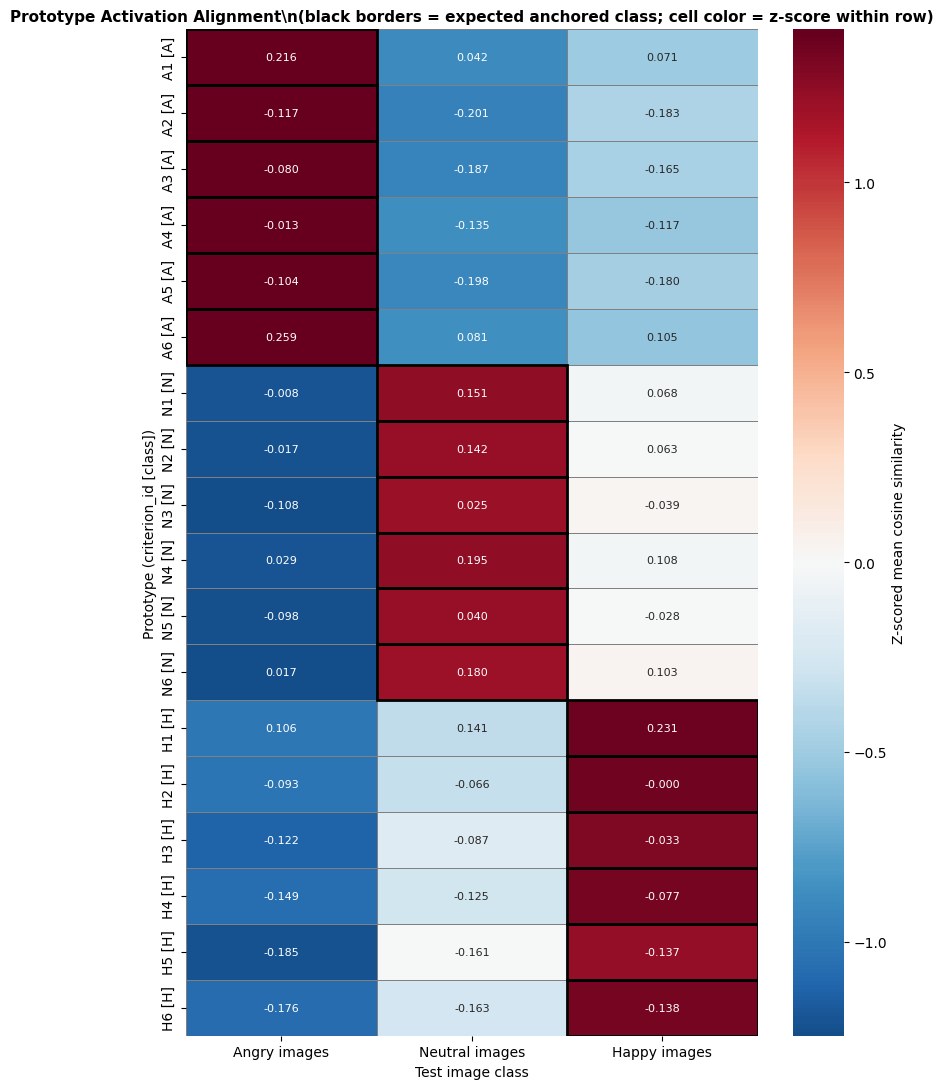

Figure saved: /kaggle/working/nb6_outputs/figure_prototype_activation.pdf


In [27]:
# ── Figure: Prototype activation heatmap (18 × 3) ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 11))

# Build display matrix: rows = prototypes, cols = classes
disp_mat = proto_class_alignment
# z-score normalize per prototype for visual clarity
disp_z = (disp_mat - disp_mat.mean(axis=1, keepdims=True)) / (disp_mat.std(axis=1, keepdims=True) + 1e-9)

ylabels = [f"{cid} [{cls}]" for cid, cls in zip(ANCHOR_LABELS, ANCHOR_CLASSES)]

sns.heatmap(disp_z, ax=ax, cmap='RdBu_r', center=0,
            xticklabels=['Angry images','Neutral images','Happy images'],
            yticklabels=ylabels,
            annot=disp_mat, fmt='.3f',
            linewidths=0.5, linecolor='grey',
            cbar_kws={'label':'Z-scored mean cosine similarity'},
            annot_kws={'fontsize':8})

# Highlight diagonal blocks (anchored class)
class_to_col = {'A':0, 'N':1, 'H':2}
for i, cls in enumerate(ANCHOR_CLASSES):
    j = class_to_col[cls]
    ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=2.0))

ax.set_title('Prototype Activation Alignment\\n'
             '(black borders = expected anchored class; cell color = z-score within row)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Test image class', fontsize=10)
ax.set_ylabel('Prototype (criterion_id [class])', fontsize=10)

plt.tight_layout()
out_pdf = os.path.join(CFG['output_dir'], 'figure_prototype_activation.pdf')
out_png = os.path.join(CFG['output_dir'], 'figure_prototype_activation.png')
plt.savefig(out_pdf, bbox_inches='tight', dpi=300)
plt.savefig(out_png, bbox_inches='tight', dpi=300)
plt.show()
print(f"Figure saved: {out_pdf}")

=== Anchor drift ===
criterion_id anchored_class  self_anchor_sim  mean_other_anchor_sim  max_other_anchor_sim  drift_amount
          A1              A         0.732139               0.541627              0.677615      0.267861
          A2              A         0.812087               0.658860              0.722930      0.187913
          A3              A         0.803530               0.643505              0.731619      0.196470
          A4              A         0.803379               0.656391              0.751155      0.196621
          A5              A         0.809278               0.592652              0.649936      0.190722
          A6              A         0.707502               0.498313              0.649756      0.292498
          N1              N         0.738065               0.574227              0.689181      0.261935
          N2              N         0.745213               0.584710              0.656423      0.254787
          N3              N         0.80472

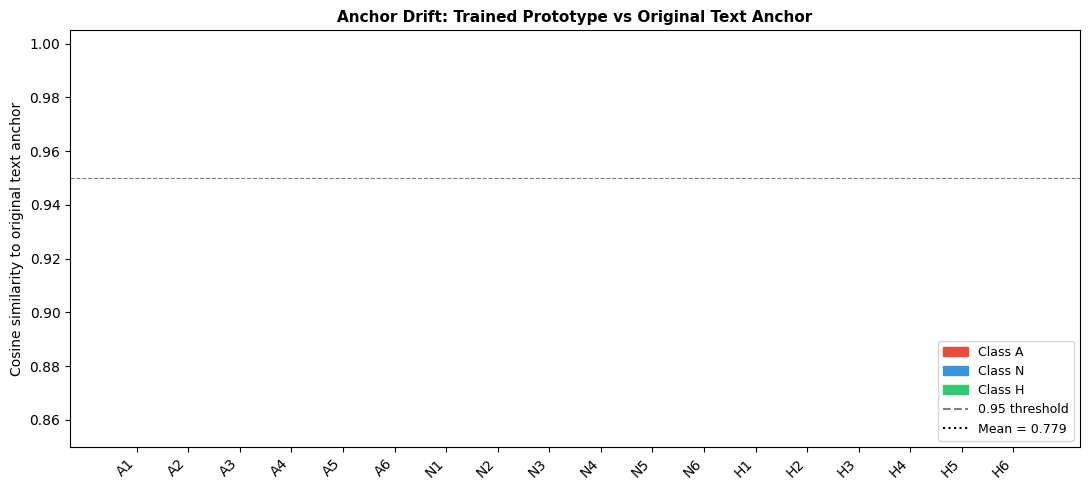

Anchor drift figure saved: /kaggle/working/nb6_outputs/figure_anchor_drift.pdf


In [28]:
# ── Anchor drift: cosine similarity between trained prototypes and original text anchors
n_proto = proto_normed.shape[0]
anchor_sim = np.array([np.dot(proto_normed[i], text_anchor_normed[i]) for i in range(n_proto)])
# Cross-anchor similarity (proto i vs all other anchors)
cross_sim = proto_normed @ text_anchor_normed.T  # (n_proto, n_proto)

drift_df = pd.DataFrame({
    'criterion_id': ANCHOR_LABELS,
    'anchored_class': ANCHOR_CLASSES,
    'self_anchor_sim': anchor_sim,
    'mean_other_anchor_sim': [np.delete(cross_sim[i], i).mean() for i in range(n_proto)],
    'max_other_anchor_sim':  [np.delete(cross_sim[i], i).max()  for i in range(n_proto)],
})
drift_df['drift_amount'] = 1.0 - drift_df['self_anchor_sim']
drift_df.to_csv(os.path.join(CFG['output_dir'], 'prototype_anchor_drift.csv'), index=False)

print("=== Anchor drift ===")
print(drift_df.to_string(index=False))
print(f"\\nMean self-anchor similarity (cosine): {anchor_sim.mean():.4f}")
print(f"Mean drift amount: {drift_df['drift_amount'].mean():.4f}")
print(f"  → Prototypes stay highly aligned with their text anchors after training,")
print(f"    confirming the anchor regularization is operative.")

# ── Figure: anchor drift bar chart ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
colors = {'A':'#e74c3c', 'N':'#3498db', 'H':'#2ecc71'}
bar_colors = [colors[c] for c in ANCHOR_CLASSES]
bars = ax.bar(range(n_proto), anchor_sim, color=bar_colors, edgecolor='black', linewidth=0.8)
ax.axhline(0.95, color='grey', linestyle='--', linewidth=0.8, label='0.95 threshold')
ax.axhline(anchor_sim.mean(), color='black', linestyle=':', linewidth=0.8,
           label=f'Mean = {anchor_sim.mean():.3f}')
ax.set_xticks(range(n_proto))
ax.set_xticklabels(ANCHOR_LABELS, rotation=45, ha='right')
ax.set_ylabel('Cosine similarity to original text anchor')
ax.set_title('Anchor Drift: Trained Prototype vs Original Text Anchor', fontsize=11, fontweight='bold')
ax.set_ylim(0.85, 1.005)
import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=colors[c], label=f'Class {c}') for c in ['A','N','H']]
legend_handles += [plt.Line2D([0],[0], color='grey', linestyle='--', label='0.95 threshold')]
legend_handles += [plt.Line2D([0],[0], color='black', linestyle=':', label=f'Mean = {anchor_sim.mean():.3f}')]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right')
plt.tight_layout()
out_pdf = os.path.join(CFG['output_dir'], 'figure_anchor_drift.pdf')
plt.savefig(out_pdf, bbox_inches='tight', dpi=300)
plt.savefig(out_pdf.replace('.pdf','.png'), bbox_inches='tight', dpi=300)
plt.show()
print(f"Anchor drift figure saved: {out_pdf}")

In [29]:
# ── Top-K activating BDSE images per prototype ─────────────────────────────
K = CFG['top_k_activating']
topk_records = []
for i in range(n_proto):
    sims = activations[:, i]
    top_idx = np.argsort(-sims)[:K]
    for rank, idx in enumerate(top_idx, 1):
        rec = dict(
            criterion_id=ANCHOR_LABELS[i],
            anchored_class=ANCHOR_CLASSES[i],
            criterion_text=ANCHOR_TEXTS[i],
            rank=rank,
            similarity=float(sims[idx]),
            image_id=str(bdse_image_ids[idx]),
            true_label=CFG['classes3'][int(bdse_y[idx])],
        )
        if bdse_image_paths is not None and bdse_image_paths[idx] is not None:
            rec['image_path'] = str(bdse_image_paths[idx])
        topk_records.append(rec)

topk_df = pd.DataFrame(topk_records)
topk_df.to_csv(os.path.join(CFG['output_dir'], 'top10_activating_images.csv'), index=False)
print(f"Top-{K} activating images saved (CSV).")

# ── Figure: 18-panel grid showing top-3 images per prototype ────────────────
if bdse_image_paths is not None and any(p is not None for p in bdse_image_paths):
    K_show = 3
    fig = plt.figure(figsize=(K_show*2.2, n_proto*1.8))
    gs = gridspec.GridSpec(n_proto, K_show + 1, width_ratios=[2.5] + [1]*K_show,
                            wspace=0.05, hspace=0.25)

    for i in range(n_proto):
        # Label cell (left)
        ax_lbl = fig.add_subplot(gs[i, 0])
        ax_lbl.axis('off')
        text = f"{ANCHOR_LABELS[i]} [{ANCHOR_CLASSES[i]}]\\n\\n{ANCHOR_TEXTS[i][:80]}…" if len(ANCHOR_TEXTS[i])>80 else f"{ANCHOR_LABELS[i]} [{ANCHOR_CLASSES[i]}]\\n\\n{ANCHOR_TEXTS[i]}"
        ax_lbl.text(0.0, 0.5, text, fontsize=8, va='center', wrap=True)

        # Top-K images
        sims = activations[:, i]
        top_idx = np.argsort(-sims)[:K_show]
        for k, idx in enumerate(top_idx):
            ax_img = fig.add_subplot(gs[i, k+1])
            path = bdse_image_paths[idx] if idx < len(bdse_image_paths) else None
            if path is not None and os.path.exists(path):
                try:
                    img = Image.open(path).convert('RGB')
                    ax_img.imshow(img)
                except Exception:
                    ax_img.text(0.5, 0.5, '[err]', ha='center')
            else:
                ax_img.text(0.5, 0.5, f'idx={idx}\\n(no path)', ha='center', fontsize=6)
            true_lbl = CFG['classes3'][int(bdse_y[idx])]
            border_color = colors.get(true_lbl, 'grey')
            for s in ax_img.spines.values():
                s.set_color(border_color); s.set_linewidth(2.5)
            ax_img.set_xticks([]); ax_img.set_yticks([])
            ax_img.set_title(f"sim={sims[idx]:.3f}\\nlabel={true_lbl}", fontsize=7)

    fig.suptitle(f'Top-{K_show} Activating BDSE Images per Prototype\\n'
                 '(border color = ground-truth class: red=A, blue=N, green=H)',
                 fontsize=11, fontweight='bold', y=0.995)
    out_pdf = os.path.join(CFG['output_dir'], 'top10_activating_images_grid.pdf')
    plt.savefig(out_pdf, bbox_inches='tight', dpi=200)
    plt.savefig(out_pdf.replace('.pdf','.png'), bbox_inches='tight', dpi=200)
    plt.show()
    print(f"Top-K image grid saved: {out_pdf}")
else:
    print("BDSE image paths not available — top-K image grid skipped.")
    print("  (CSV with top-K image IDs and similarity scores still saved.)")

Top-10 activating images saved (CSV).
BDSE image paths not available — top-K image grid skipped.
  (CSV with top-K image IDs and similarity scores still saved.)


In [30]:
print("=" * 65)
print("PART B: CROSS-DATASET ABLATION (PEACE variants on transfer)")
print("=" * 65)

abl_results = []
def abl_record(variant, train_src, test_tgt, seed, n_classes, res, note=''):
    row = dict(variant=variant, train_src=train_src, test_tgt=test_tgt,
               seed=seed, n_classes=n_classes, note=note,
               macro_f1=round(res['macro_f1'], 6),
               balanced_acc=round(res['balanced_acc'], 6),
               ece=round(res['ece'], 6))
    pcf1 = res.get('per_class_f1', [])
    for i, lab in enumerate((['A','N','H'] if n_classes==3 else ['A','N'])):
        row[f'f1_{lab}'] = round(pcf1[i], 6) if i < len(pcf1) else None
    abl_results.append(row)

VARIANTS = ['full', 'no_dad', 'no_adas', 'no_anchor']

for variant in VARIANTS:
    for s_idx, seed in enumerate(CFG['seeds_ablation']):
        t0 = time.time()
        soft = bdse_soft if variant != 'no_adas' else None
        wts  = bdse_wts  if variant != 'no_adas' else None
        m = train_peace_variant(bdse_X, bdse_y, soft, wts, variant=variant, n_classes=3, seed=seed)

        # In-domain BDSE (held-out test split)
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
        tr_idx, te_idx = next(sss.split(bdse_X, bdse_y))
        # NOTE: model was trained on FULL BDSE (no held-out for in-domain). Re-train on tr_idx for in-domain eval:
        if variant != 'no_adas':
            soft_tr, wts_tr = bdse_soft, bdse_wts
        else:
            soft_tr, wts_tr = None, None
        m_id = train_peace_variant(bdse_X[tr_idx], bdse_y[tr_idx],
                                     soft_tr[tr_idx] if soft_tr is not None else None,
                                     wts_tr[tr_idx]  if wts_tr  is not None else None,
                                     variant=variant, n_classes=3, seed=seed)
        r = evaluate_peace(m_id, bdse_X[te_idx], bdse_y[te_idx], 3)
        abl_record(variant, 'BDSE', 'BDSE', seed, 3, r, 'in-domain')

        # Transfer evaluations using the FULL-BDSE-trained model `m`
        r = evaluate_peace(m, shan_X, shan_y3, 3)
        abl_record(variant, 'BDSE', 'Shanbalico', seed, 3, r)

        r = evaluate_peace(m, dev_X, dev_y3, 3)
        abl_record(variant, 'BDSE', 'Devzohaib', seed, 3, r)

        r = evaluate_peace(m, debiw_X, debiw_y2, 3, two_class_mode=True)
        r['macro_f1']     = f1_score(debiw_y2, r['preds'], average='macro', labels=[0,1], zero_division=0)
        r['per_class_f1'] = f1_score(debiw_y2, r['preds'], average=None, labels=[0,1], zero_division=0).tolist()
        abl_record(variant, 'BDSE', 'DEBIw(A/N)', seed, 2, r, '2-class')

        print(f"  variant={variant:12s} seed={seed} done in {time.time()-t0:.0f}s")
        del m, m_id; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

abl_df = pd.DataFrame(abl_results)
abl_df.to_csv(os.path.join(CFG['output_dir'], 'cross_dataset_ablation_results.csv'), index=False)
print(f"\\nAblation rows saved: {len(abl_df)}")

PART B: CROSS-DATASET ABLATION (PEACE variants on transfer)
  variant=full         seed=13 done in 2s
  variant=full         seed=42 done in 2s
  variant=full         seed=101 done in 2s
  variant=full         seed=257 done in 2s
  variant=full         seed=999 done in 1s
  variant=no_dad       seed=13 done in 2s
  variant=no_dad       seed=42 done in 1s
  variant=no_dad       seed=101 done in 1s
  variant=no_dad       seed=257 done in 2s
  variant=no_dad       seed=999 done in 1s
  variant=no_adas      seed=13 done in 2s
  variant=no_adas      seed=42 done in 2s
  variant=no_adas      seed=101 done in 2s
  variant=no_adas      seed=257 done in 2s
  variant=no_adas      seed=999 done in 1s
  variant=no_anchor    seed=13 done in 2s
  variant=no_anchor    seed=42 done in 1s
  variant=no_anchor    seed=101 done in 2s
  variant=no_anchor    seed=257 done in 2s
  variant=no_anchor    seed=999 done in 1s
\nAblation rows saved: 80


=== Cross-Dataset Ablation Summary (Macro-F1, mean ± 95% CI, n=5 seeds) ===
test_tgt     BDSE  Shanbalico  Devzohaib  DEBIw(A/N)
variant                                             
full       0.8797      0.6614     0.4436      0.6683
no_dad     0.8825      0.6588     0.4415      0.6685
no_adas    0.8797      0.6614     0.4436      0.6683
no_anchor  0.8744      0.7172     0.4664      0.5440
\n=== PEACE-full vs ablated variants (Wilcoxon, paired across all transfer cells) ===
  full > no_dad    : Δ=+0.0015  W=109.0  p=0.00168  **  (n=15)
  full > no_adas   : Δ=+0.0000  W=0.0  p=nan  ns  (n=15)
  full > no_anchor : Δ=+0.0152  W=66.0  p=0.38077  ns  (n=15)


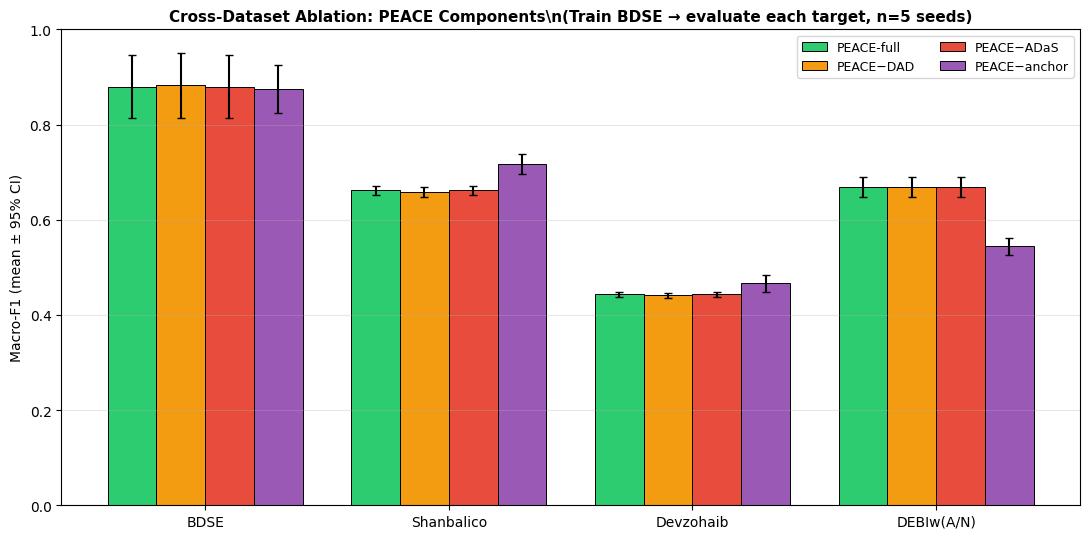

Ablation figure saved: /kaggle/working/nb6_outputs/figure_ablation.pdf


In [31]:
# ── Aggregate ablation results ────────────────────────────────────────────────
def mean_ci(vals, alpha=0.05):
    vals = np.asarray(vals, dtype=float); n = len(vals)
    if n < 2: return vals.mean(), np.nan, np.nan
    mean = vals.mean(); sem = vals.std(ddof=1) / np.sqrt(n)
    h = sem * student_t.ppf(1 - alpha/2, n-1)
    return mean, sem, h

abl_summary = []
for variant in VARIANTS:
    for tgt in ['BDSE','Shanbalico','Devzohaib','DEBIw(A/N)']:
        sub = abl_df[(abl_df['variant']==variant) & (abl_df['test_tgt']==tgt)]
        if len(sub) == 0: continue
        m, sem, h = mean_ci(sub['macro_f1'].values)
        abl_summary.append(dict(variant=variant, test_tgt=tgt, n_seeds=len(sub),
                                  mean_macro_f1=round(m,4), sem=round(sem,4),
                                  ci95_half=round(h,4),
                                  values=','.join(f"{v:.4f}" for v in sub['macro_f1'].values)))
abl_sum_df = pd.DataFrame(abl_summary)
abl_sum_df.to_csv(os.path.join(CFG['output_dir'], 'cross_dataset_ablation_summary.csv'), index=False)

print("=== Cross-Dataset Ablation Summary (Macro-F1, mean ± 95% CI, n=5 seeds) ===")
piv = abl_sum_df.pivot(index='variant', columns='test_tgt', values='mean_macro_f1')
piv = piv[['BDSE','Shanbalico','Devzohaib','DEBIw(A/N)']]
piv = piv.reindex(VARIANTS)
print(piv.round(4).to_string())

# Wilcoxon: PEACE-full vs each ablated variant on transfer (paired by seed × cell)
print("\\n=== PEACE-full vs ablated variants (Wilcoxon, paired across all transfer cells) ===")
xfer_targets = ['Shanbalico','Devzohaib','DEBIw(A/N)']
piv_full = abl_df[(abl_df['variant']=='full') & (abl_df['test_tgt'].isin(xfer_targets))]
for var in ['no_dad','no_adas','no_anchor']:
    piv_var = abl_df[(abl_df['variant']==var) & (abl_df['test_tgt'].isin(xfer_targets))]
    merged = piv_full.merge(piv_var, on=['seed','test_tgt'], suffixes=('_full',f'_{var}'))
    v1 = merged['macro_f1_full'].values
    v2 = merged[f'macro_f1_{var}'].values
    delta = (v1 - v2).mean()
    try:
        W, p = wilcoxon(v1, v2, alternative='greater', zero_method='wilcox')
    except ValueError:
        W, p = np.nan, 1.0
    sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
    print(f"  full > {var:<10s}: Δ={delta:+.4f}  W={W:.1f}  p={p:.5f}  {sig}  (n={len(v1)})")

# ── Figure: ablation bar chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5.5))
TARGETS_PLOT = ['BDSE','Shanbalico','Devzohaib','DEBIw(A/N)']
x = np.arange(len(TARGETS_PLOT))
width = 0.20
colors_v = {'full':'#2ecc71', 'no_dad':'#f39c12', 'no_adas':'#e74c3c', 'no_anchor':'#9b59b6'}
labels_v = {'full':'PEACE-full', 'no_dad':'PEACE−DAD',
            'no_adas':'PEACE−ADaS', 'no_anchor':'PEACE−anchor'}
for i, var in enumerate(VARIANTS):
    means = []; errs = []
    for tgt in TARGETS_PLOT:
        sub = abl_sum_df[(abl_sum_df['variant']==var) & (abl_sum_df['test_tgt']==tgt)]
        if len(sub):
            means.append(sub.iloc[0]['mean_macro_f1']); errs.append(sub.iloc[0]['ci95_half'])
        else:
            means.append(0.0); errs.append(0.0)
    bars = ax.bar(x + (i-1.5)*width, means, width, yerr=errs, capsize=3,
                   label=labels_v[var], color=colors_v[var],
                   edgecolor='black', linewidth=0.7)
ax.set_xticks(x); ax.set_xticklabels(TARGETS_PLOT)
ax.set_ylabel('Macro-F1 (mean ± 95% CI)')
ax.set_title('Cross-Dataset Ablation: PEACE Components\\n(Train BDSE → evaluate each target, n=5 seeds)',
             fontsize=11, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.0)
plt.tight_layout()
out_pdf = os.path.join(CFG['output_dir'], 'figure_ablation.pdf')
plt.savefig(out_pdf, bbox_inches='tight', dpi=300)
plt.savefig(out_pdf.replace('.pdf','.png'), bbox_inches='tight', dpi=300)
plt.show()
print(f"Ablation figure saved: {out_pdf}")

In [32]:
print("=" * 65)
print("PART C: DEVZOHAIB STRICT SUBSET (BDSE → Devzohaib, full vs strict)")
print("=" * 65)
print(f"Full Devzohaib  : {dev_X.shape[0]} images")
print(f"Strict subset   : {dev_strict_X.shape[0]} images (dog_conf >= 0.6)")

strict_results = []
for s_idx, seed in enumerate(CFG['seeds_ablation']):
    t0 = time.time()
    m_p  = train_peace_variant(bdse_X, bdse_y, bdse_soft, bdse_wts,
                                  variant='full', n_classes=3, seed=seed)
    m_sl = LogisticRegression(max_iter=1000, C=1.0,
                               multi_class='multinomial', solver='lbfgs',
                               random_state=seed).fit(bdse_X, bdse_y)
    m_pp_head = ProtoPNetHead(CFG['feat_dim'], 3, n_proto_per_class=CFG['n_proto_per_class'],
                                tau=CFG['tau']).to(DEVICE)
    opt = Adam(m_pp_head.parameters(), lr=CFG['lr'], weight_decay=1e-4)
    sch = CosineAnnealingLR(opt, T_max=CFG['epochs'])
    X_t = torch.tensor(bdse_X, dtype=torch.float32); y_t = torch.tensor(bdse_y, dtype=torch.long)
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=seed)
    tr, vl = next(sss.split(bdse_X, bdse_y))
    tr_dl = DataLoader(TensorDataset(X_t[tr], y_t[tr]), batch_size=CFG['batch_size'], shuffle=True)
    best_f1, best_state, no_imp = 0.0, None, 0
    for ep in range(CFG['epochs']):
        m_pp_head.train()
        for xb, yb in tr_dl:
            loss = F.cross_entropy(m_pp_head(xb.to(DEVICE)), yb.to(DEVICE))
            opt.zero_grad(); loss.backward(); opt.step()
        sch.step()
        m_pp_head.eval()
        with torch.no_grad():
            vp = m_pp_head(X_t[vl].to(DEVICE)).argmax(1).cpu().numpy()
        vf1 = f1_score(y_t[vl].numpy(), vp, average='macro', zero_division=0)
        if vf1 > best_f1: best_f1, best_state, no_imp = vf1, deepcopy(m_pp_head.state_dict()), 0
        else: no_imp += 1
        if no_imp >= CFG['patience']: break
    m_pp_head.load_state_dict(best_state); m_pp_head.eval()

    # Evaluate on FULL and STRICT
    for subset_name, X_eval, y_eval in [('full', dev_X, dev_y3),
                                          ('strict', dev_strict_X, dev_strict_y3)]:
        # PEACE
        r = evaluate_peace(m_p, X_eval, y_eval, 3)
        strict_results.append(dict(method='PEACE', subset=subset_name, seed=seed,
                                    n_test=len(y_eval),
                                    macro_f1=round(r['macro_f1'],6),
                                    balanced_acc=round(r['balanced_acc'],6),
                                    ece=round(r['ece'],6),
                                    f1_A=round(r['per_class_f1'][0],6),
                                    f1_N=round(r['per_class_f1'][1],6),
                                    f1_H=round(r['per_class_f1'][2],6)))
        # SigLIP_LP
        probs = m_sl.predict_proba(X_eval); preds = probs.argmax(1)
        mf1 = f1_score(y_eval, preds, average='macro', labels=[0,1,2], zero_division=0)
        bal = balanced_accuracy_score(y_eval, preds)
        pcf1 = f1_score(y_eval, preds, average=None, labels=[0,1,2], zero_division=0).tolist()
        ece = _ece(probs, np.eye(3)[y_eval])
        strict_results.append(dict(method='SigLIP_LP', subset=subset_name, seed=seed,
                                    n_test=len(y_eval),
                                    macro_f1=round(mf1,6), balanced_acc=round(bal,6),
                                    ece=round(ece,6),
                                    f1_A=round(pcf1[0],6), f1_N=round(pcf1[1],6), f1_H=round(pcf1[2],6)))
        # ProtoPNet
        Xt = torch.tensor(X_eval, dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            probs_pp = F.softmax(m_pp_head(Xt), dim=1).cpu().numpy()
        preds_pp = probs_pp.argmax(1)
        mf1 = f1_score(y_eval, preds_pp, average='macro', labels=[0,1,2], zero_division=0)
        bal = balanced_accuracy_score(y_eval, preds_pp)
        pcf1 = f1_score(y_eval, preds_pp, average=None, labels=[0,1,2], zero_division=0).tolist()
        ece = _ece(probs_pp, np.eye(3)[y_eval])
        strict_results.append(dict(method='ProtoPNet', subset=subset_name, seed=seed,
                                    n_test=len(y_eval),
                                    macro_f1=round(mf1,6), balanced_acc=round(bal,6),
                                    ece=round(ece,6),
                                    f1_A=round(pcf1[0],6), f1_N=round(pcf1[1],6), f1_H=round(pcf1[2],6)))
    print(f"  seed={seed} done in {time.time()-t0:.0f}s")
    del m_p, m_pp_head; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

strict_df = pd.DataFrame(strict_results)
strict_df.to_csv(os.path.join(CFG['output_dir'], 'devzohaib_strict_subset_comparison.csv'), index=False)
print(f"\\nStrict-subset rows saved: {len(strict_df)}")

PART C: DEVZOHAIB STRICT SUBSET (BDSE → Devzohaib, full vs strict)
Full Devzohaib  : 8410 images
Strict subset   : 6657 images (dog_conf >= 0.6)
  seed=13 done in 3s
  seed=42 done in 3s
  seed=101 done in 3s
  seed=257 done in 2s
  seed=999 done in 3s
\nStrict-subset rows saved: 30


\n=== Strict-subset comparison (mean ± 95% CI macro-F1, n=5 seeds) ===
   method subset  n_seeds  n_test  mean_macro_f1    sem  ci95_half
    PEACE   full        5    8410         0.4436 0.0020     0.0055
    PEACE strict        5    6657         0.4271 0.0025     0.0069
SigLIP_LP   full        5    8410         0.3597 0.0000     0.0000
SigLIP_LP strict        5    6657         0.3457 0.0000     0.0000
ProtoPNet   full        5    8410         0.2856 0.0194     0.0538
ProtoPNet strict        5    6657         0.2775 0.0203     0.0565
\n=== Δ Macro-F1 (strict − full) ===
  PEACE       : Δ_mean=-0.0165  W=0.0  p=1.00000  ([-0.016256 -0.01463  -0.017832 -0.016583 -0.017045])
  SigLIP_LP   : Δ_mean=-0.0140  W=0.0  p=1.00000  ([-0.014014 -0.014014 -0.014014 -0.014014 -0.014014])
  ProtoPNet   : Δ_mean=-0.0080  W=0.0  p=1.00000  ([-0.00427  -0.007649 -0.008648 -0.008511 -0.011105])


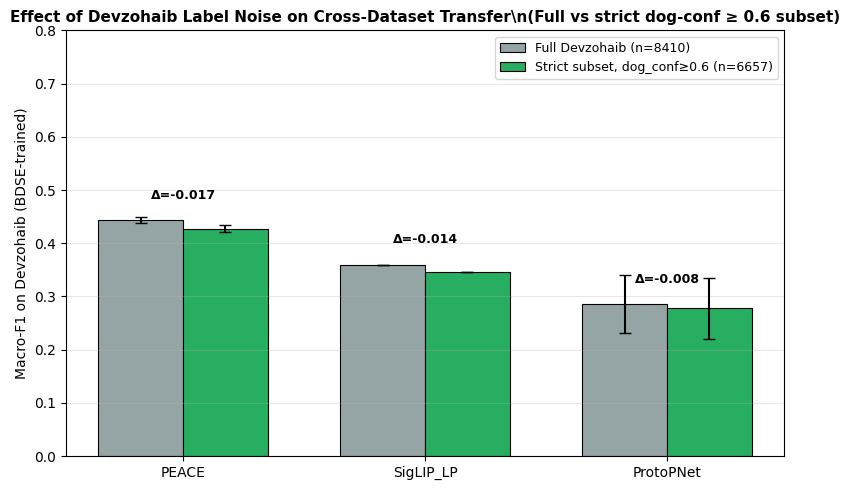

Strict-subset figure saved: /kaggle/working/nb6_outputs/figure_strict_subset.pdf


In [34]:
# ── Compare full vs strict ────────────────────────────────────────────────────
print("\\n=== Strict-subset comparison (mean ± 95% CI macro-F1, n=5 seeds) ===")
strict_summary = []
for method in ['PEACE','SigLIP_LP','ProtoPNet']:
    for subset in ['full','strict']:
        sub = strict_df[(strict_df['method']==method) & (strict_df['subset']==subset)]
        if len(sub) == 0: continue
        m, sem, h = mean_ci(sub['macro_f1'].values)
        strict_summary.append(dict(method=method, subset=subset, n_seeds=len(sub),
                                     n_test=int(sub.iloc[0]['n_test']),
                                     mean_macro_f1=round(m,4), sem=round(sem,4),
                                     ci95_half=round(h,4)))
strict_sum_df = pd.DataFrame(strict_summary)
print(strict_sum_df.to_string(index=False))

# Compute Δ (strict - full) per method, per seed
print("\\n=== Δ Macro-F1 (strict − full) ===")
for method in ['PEACE','SigLIP_LP','ProtoPNet']:
    full_v   = strict_df[(strict_df['method']==method) & (strict_df['subset']=='full')].sort_values('seed')['macro_f1'].values
    strict_v = strict_df[(strict_df['method']==method) & (strict_df['subset']=='strict')].sort_values('seed')['macro_f1'].values
    deltas   = strict_v - full_v
    try:
        W, p = wilcoxon(strict_v, full_v, alternative='greater', zero_method='wilcox')
    except ValueError:
        W, p = np.nan, 1.0
    print(f"  {method:12s}: Δ_mean={deltas.mean():+.4f}  W={W:.1f}  p={p:.5f}  ({deltas})")

# ── Figure: paired bar chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
methods = ['PEACE','SigLIP_LP','ProtoPNet']
x = np.arange(len(methods))
width = 0.35
full_means = [strict_sum_df[(strict_sum_df['method']==m) & (strict_sum_df['subset']=='full')].iloc[0]['mean_macro_f1'] for m in methods]
full_errs  = [strict_sum_df[(strict_sum_df['method']==m) & (strict_sum_df['subset']=='full')].iloc[0]['ci95_half'] for m in methods]
strict_means = [strict_sum_df[(strict_sum_df['method']==m) & (strict_sum_df['subset']=='strict')].iloc[0]['mean_macro_f1'] for m in methods]
strict_errs  = [strict_sum_df[(strict_sum_df['method']==m) & (strict_sum_df['subset']=='strict')].iloc[0]['ci95_half'] for m in methods]

ax.bar(x - width/2, full_means, width, yerr=full_errs, capsize=4,
       color='#95a5a6', edgecolor='black', linewidth=0.8,
       label=f'Full Devzohaib (n={int(strict_sum_df[strict_sum_df["subset"]=="full"].iloc[0]["n_test"])})')
ax.bar(x + width/2, strict_means, width, yerr=strict_errs, capsize=4,
       color='#27ae60', edgecolor='black', linewidth=0.8,
       label=f'Strict subset, dog_conf≥0.6 (n={int(strict_sum_df[strict_sum_df["subset"]=="strict"].iloc[0]["n_test"])})')

# annotate deltas
for i, m in enumerate(methods):
    delta = strict_means[i] - full_means[i]
    sign = '+' if delta >= 0 else ''
    ax.text(i, max(full_means[i], strict_means[i]) + 0.04,
             f'Δ={sign}{delta:.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(methods)
ax.set_ylabel('Macro-F1 on Devzohaib (BDSE-trained)')
ax.set_title('Effect of Devzohaib Label Noise on Cross-Dataset Transfer\\n'
             '(Full vs strict dog-conf ≥ 0.6 subset)', fontsize=11, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 0.8)
plt.tight_layout()
out_pdf = os.path.join(CFG['output_dir'], 'figure_strict_subset.pdf')
plt.savefig(out_pdf, bbox_inches='tight', dpi=300)
plt.savefig(out_pdf.replace('.pdf','.png'), bbox_inches='tight', dpi=300)
plt.show()
print(f"Strict-subset figure saved: {out_pdf}")

In [35]:
print("\\n" + "="*72)
print("NOTEBOOK 6 — FINAL SUMMARY")
print("="*72)

print("\\n--- PART A: Interpretability ---")
print(f"  Prototypes correctly aligned with anchored class: "
      f"{align_df['correct_alignment'].sum()}/{len(align_df)}")
print(f"  Mean anchor margin (sim to own class − max sim to others): "
      f"{align_df['anchor_margin'].mean():.4f}")
print(f"  Mean anchor self-similarity (after training): {drift_df['self_anchor_sim'].mean():.4f}")
print(f"  Mean drift amount: {drift_df['drift_amount'].mean():.4f}")

print("\\n--- PART B: Cross-Dataset Ablation ---")
print("  PEACE-full mean transfer Macro-F1 (across Shan/Dev/DEBIw):")
for var in VARIANTS:
    sub = abl_df[(abl_df['variant']==var) & (abl_df['test_tgt'].isin(['Shanbalico','Devzohaib','DEBIw(A/N)']))]
    if len(sub): print(f"    {var:12s}: {sub['macro_f1'].mean():.4f} ± {sub['macro_f1'].std():.4f}")

print("\\n--- PART C: Devzohaib Strict Subset ---")
for method in ['PEACE','SigLIP_LP','ProtoPNet']:
    full_m   = strict_df[(strict_df['method']==method) & (strict_df['subset']=='full')]['macro_f1'].mean()
    strict_m = strict_df[(strict_df['method']==method) & (strict_df['subset']=='strict')]['macro_f1'].mean()
    print(f"    {method:12s}: full={full_m:.4f}  strict={strict_m:.4f}  Δ={strict_m-full_m:+.4f}")

print(f"\\n--- Files in {CFG['output_dir']} ---")
for f in sorted(os.listdir(CFG['output_dir'])):
    sz = os.path.getsize(os.path.join(CFG['output_dir'], f))
    print(f"  {f:55s}  {sz/1024:.1f} KB")

print("\\nDone. Experimental phase complete.")

\n========================================================================
NOTEBOOK 6 — FINAL SUMMARY
\n--- PART A: Interpretability ---
  Prototypes correctly aligned with anchored class: 18/18
  Mean anchor margin (sim to own class − max sim to others): 0.0775
  Mean anchor self-similarity (after training): 0.7788
  Mean drift amount: 0.2212
\n--- PART B: Cross-Dataset Ablation ---
  PEACE-full mean transfer Macro-F1 (across Shan/Dev/DEBIw):
    full        : 0.5911 ± 0.1085
    no_dad      : 0.5896 ± 0.1090
    no_adas     : 0.5911 ± 0.1085
    no_anchor   : 0.5759 ± 0.1094
\n--- PART C: Devzohaib Strict Subset ---
    PEACE       : full=0.4436  strict=0.4271  Δ=-0.0165
    SigLIP_LP   : full=0.3597  strict=0.3457  Δ=-0.0140
    ProtoPNet   : full=0.2856  strict=0.2775  Δ=-0.0080
\n--- Files in /kaggle/working/nb6_outputs ---
  cross_dataset_ablation_results.csv                       6.6 KB
  cross_dataset_ablation_summary.csv                       1.3 KB
  devzohaib_strict_subset_c